## KS Equation

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import scipy.linalg

In [3]:
L = 50.0
N = 200
dx = L/N
dt = 0.1
n_steps = int(1e6)

In [4]:
x = np.linspace(-25, 25, N, endpoint=False)
dataset = np.zeros((n_steps, N))

rng = np.random.default_rng(seed=42)
u_current = np.zeros(N)

# Excite all 7 linearly unstable modes with random amplitudes and phases
for n_mode in range(1, 8):
    k = 2 * np.pi * n_mode / L
    amp   = rng.standard_normal()
    phase = rng.uniform(0, 2 * np.pi)
    u_current += amp * np.sin(k * x + phase)

u_current *= 0.1   # small amplitude so linear instability drives initial growth
dataset[0] = u_current

In [5]:
'''
x = np.linspace(-25, 25, N, endpoint=False)
dataset = np.zeros((n_steps, N))
u_current = np.sin(x) * np.exp(-((x - 10)**2) / 2)
dataset[0] = u_current
'''
L_matrix = np.zeros((N, N))
for i in range(N):
    #Below calculation of indices to enforce the periodic boundary condition. 
    i_minus_2 = (i - 2) % N
    i_minus_1 = (i - 1) % N
    i_plus_1 = (i + 1) % N
    i_plus_2 = (i + 2) % N
    
    L_matrix[i, i_minus_1] -= 1.0 / (dx**2)
    L_matrix[i, i] -= -2.0 / (dx**2)
    L_matrix[i, i_plus_1] -= 1.0 / (dx**2)
    L_matrix[i, i_minus_2] -= 1.0 / (dx**4)
    L_matrix[i, i_minus_1] -= -4.0 / (dx**4)
    L_matrix[i, i] -= 6.0 / (dx**4)
    L_matrix[i, i_plus_1] -= -4.0 / (dx**4)
    L_matrix[i, i_plus_2] -= 1.0 / (dx**4)

In [6]:
Identity = np.eye(N)
Matrix_A = Identity - (0.5 * dt) * L_matrix
Matrix_B = Identity + (0.5 * dt) * L_matrix

In [7]:
def calc_nonlinear_term(u):
    u_squared = 0.5 * u**2
    derivative = (np.roll(u_squared,-1) - np.roll(u_squared,1))/(2 * dx)
    return -derivative

In [8]:
NonLinear_current = calc_nonlinear_term(u_current)
RHS_vector = np.dot(Matrix_B, u_current) + dt * NonLinear_current
u_next = scipy.linalg.solve(Matrix_A, RHS_vector)

dataset[1] = u_next
u_prev = u_current
u_current = u_next

In [9]:
print("Starting CN-AB2 time integration...")

for n in range(2, n_steps):
    NonLinear_n = calc_nonlinear_term(u_current)
    NonLinear_n_minus_1 = calc_nonlinear_term(u_prev)
    #Here for the Non-Linear (Non-Stiff) term, we use the Adam-BashForth 2 step method
    RHS_vector = np.dot(Matrix_B, u_current) + dt * (1.5 * NonLinear_n - 0.5 * NonLinear_n_minus_1)
    u_next = scipy.linalg.solve(Matrix_A, RHS_vector)
    dataset[n] = u_next
    u_prev = u_current
    u_current = u_next
    if n % 50000 == 0:
        print(f"Completed {n} time steps...")

print("Simulation finished successfully!")
np.save("ks_dataset_imex.npy", dataset)

Starting CN-AB2 time integration...
Completed 50000 time steps...
Completed 100000 time steps...
Completed 150000 time steps...
Completed 200000 time steps...
Completed 250000 time steps...
Completed 300000 time steps...
Completed 350000 time steps...
Completed 400000 time steps...
Completed 450000 time steps...
Completed 500000 time steps...
Completed 550000 time steps...
Completed 600000 time steps...
Completed 650000 time steps...
Completed 700000 time steps...
Completed 750000 time steps...
Completed 800000 time steps...
Completed 850000 time steps...
Completed 900000 time steps...
Completed 950000 time steps...
Simulation finished successfully!


In [18]:
dataset = np.load("ks_dataset_imex.npy")

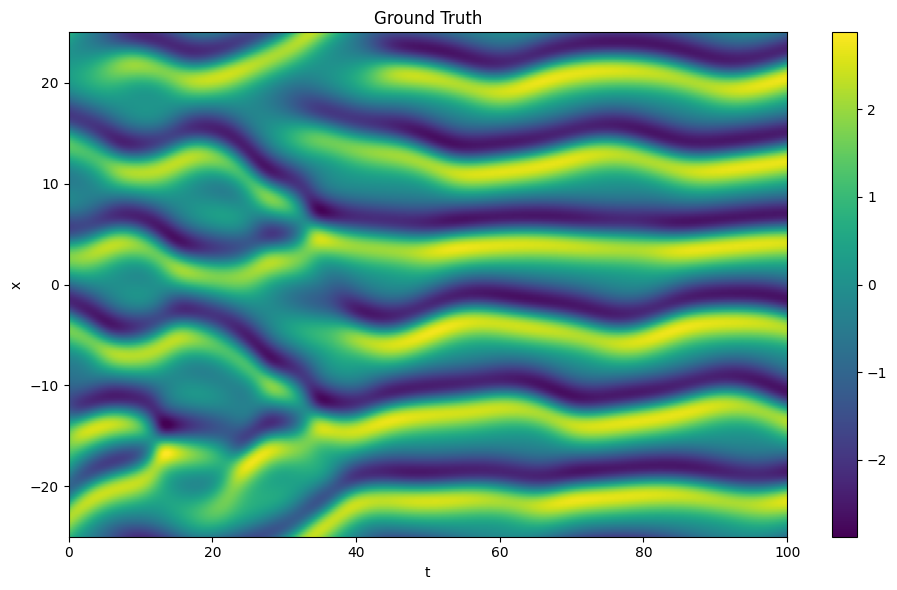

In [26]:
data_slice=dataset[-1000:,:]
plot_data=data_slice.T

dt=0.1
x_min,x_max=-25,25

t_start = 0
t_end = data_slice.shape[0] * dt 

plt.figure(figsize=(10,6))
plt.imshow(plot_data,
           aspect='auto',
           origin='lower',
           extent=[t_start,t_end,x_min,x_max],
           cmap='viridis',
           vmin=-2.88,
           vmax=2.88)

plt.title("Ground Truth")
plt.xlabel("t")
plt.ylabel("x")
plt.xticks([0, 20, 40, 60, 80, 100])
plt.tight_layout()
plt.colorbar()
plt.show()